## Prince Component Analysis:(PCA)

Principal Component Analysis (PCA) is a technique used to reduce the number of    
features (dimensions) in a dataset while keeping as much important information as possible.  
Preserving direction with maximal spread variance


### PCA Solution
•	Reduces dimensions   
•	Removes redundancy   
•	Speeds up training   
•	Helps visualization   
•	Reduces noise  


principal Component Analysis (PCA) is an unsupervised dimensionality reduction technique that transforms correlated features into a smaller set of uncorrelated variables called principal components, which capture the maximum variance in the data while minimizing information loss.

PCA steps    
1.Column standardization   
2.covarience matrix   
3. Eigan value ‘f’ and Eigan vector ‘s’  
4. u1 is to v1 (max varience )  
5. transform source of raw data with Eigen vector   

λ = what percentage of variance explained  (xiT * v1)  


In [45]:
# MNIST dataset downloaded from Kaggle : 
#https://www.kaggle.com/c/digit-recognizer/data

# Functions to read and show images.

import numpy as np  # load NumPy for numerical array operations
import pandas as pd  # load pandas for data reading and frame handling
import matplotlib.pyplot as plt  # load matplotlib for plotting
d0 = pd.read_csv('train.csv')  # read MNIST training CSV into a DataFrame
print(d0.head(5))

   label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0      1       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       0       0       0   
2      1       0       0       0       0       0       0       0       0   
3      4       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel8  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel780  pixel781  pixel782  pixel783  
0         0         0         

In [46]:
l = d0['label']  # save the 'label' column separately as target labels
d = d0.drop("label", axis=1)  # drop the label column to keep only pixel features


In [47]:
print(d.head(5))

   pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0       0       0       0       0       0       0       0       0       0   
1       0       0       0       0       0       0       0       0       0   
2       0       0       0       0       0       0       0       0       0   
3       0       0       0       0       0       0       0       0       0   
4       0       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel780  pixel781  pixel782  pixel783  
0         0         0   

In [48]:
print(d.shape)  # print shape of the data matrix (rows, pixels)

(42000, 784)


In [49]:
print(l.shape)

(42000,)


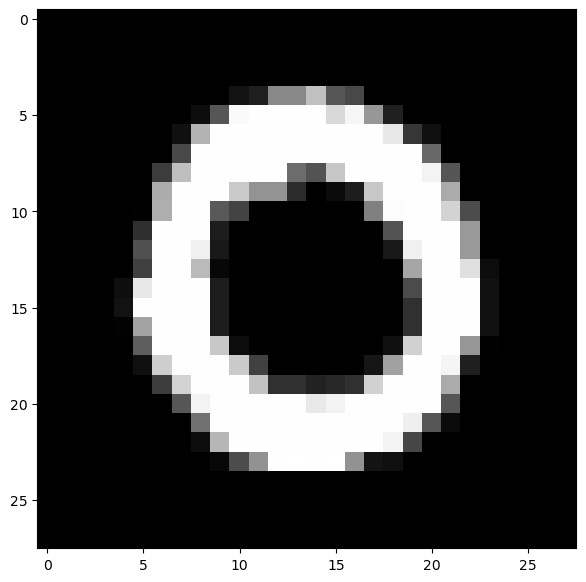

0


In [50]:
# display or plot a number.
plt.figure(figsize=(7,7))  # create a new figure with a square size
idx = 1  # select an index to display

grid_data = d.iloc[idx].to_numpy().reshape(28,28)  # convert the selected row into a 28x28 pixel grid
plt.imshow(grid_data, interpolation="none", cmap="gray")  # show the image in grayscale
plt.show()  # render the plot
print(l[idx])  # print the true label for the displayed image

In [51]:
# Pick first 15K data-points to work on for time-effeciency.
#Excercise: Perform the same analysis on all of 42K data-points.

In [52]:
labels = l.head(15000)
data = d.head(15000)  # take first 15000 feature rows for the sample
print("the shape of sample data = ", data.shape)  # print sample shape

the shape of sample data =  (15000, 784)


In [53]:
# Data-preprocessing: Standardizing the data

from sklearn.preprocessing import StandardScaler  # import scaler for standardization
standardized_data = StandardScaler().fit_transform(data)  # fit and transform data to zero mean and unit variance
print(standardized_data.shape)  # print shape of standardized data

(15000, 784)


In [54]:
#find the co-variance matrix which is : A^T * A
sample_data = standardized_data  # use standardized data as the working sample

# matrix multiplication using numpy
covar_matrix = np.matmul(sample_data.T, sample_data)  # compute covariance matrix from standardized data
print("The shape of variance matrix = ", covar_matrix.shape)  # print covariance matrix shape

The shape of variance matrix =  (784, 784)


In [55]:
# finding the top two eigen-values and corresponding eigen-vectors 
# for projecting onto a 2-Dim space.

from scipy.linalg import eigh  # import eigen decomposition for symmetric matrices

# the parameter 'eigvals' is defined (low value to heigh value) 
# eigh function will return the eigen values in asending order
# this code generates only the top 2 (782 and 783) eigenvalues.
values, vectors = eigh(covar_matrix, subset_by_index=[782, 783])  # compute the top two eigenvalues and eigenvectors

print("Shape of eigen vectors = ", vectors.shape)  # print shape of the returned eigenvector matrix
vectors = vectors.T  # transpose so each row is an eigenvector for easier projection
print("Updated shape of eigen vectors = ", vectors.shape)  # print shape after transpose
# here the vectors[1] represent the eigen vector corresponding 1st principal eigen vector
# here the vectors[0] represent the eigen vector corresponding 2nd principal eigen vector

Shape of eigen vectors =  (784, 2)
Updated shape of eigen vectors =  (2, 784)


In [56]:
#projecting the original data sample on the plane 
#formed by two principal eigen vectors by vector-vector multiplication.

import matplotlib.pyplot as plt
new_coordinates = np.matmul(vectors, sample_data.T)

print (" resultanat new data points' shape ", vectors.shape, "X", sample_data.T.shape," = ", new_coordinates.shape)

 resultanat new data points' shape  (2, 784) X (784, 15000)  =  (2, 15000)


In [57]:
import pandas as pd

# appending label to the 2d projected data
new_coordinates = np.vstack((new_coordinates, labels)).T

# creating a new data frame for ploting the labeled points.
dataframe = pd.DataFrame(data=new_coordinates, columns=("1st_principal", "2nd_principal", "label"))
print(dataframe.head())

   1st_principal  2nd_principal  label
0      -5.558661      -5.043558    1.0
1       6.193635      19.305278    0.0
2      -1.909878      -7.678775    1.0
3       5.525748      -0.464845    4.0
4       6.366527      26.644289    0.0


In [58]:
import pandas as pd
df=pd.DataFrame()
df['1st']=[-5.558661,-5.043558,6.193635 ,19.305278]
df['2nd']=[-1.558661,-2.043558,2.193635 ,9.305278]
df['label']=[1,2,3,4]

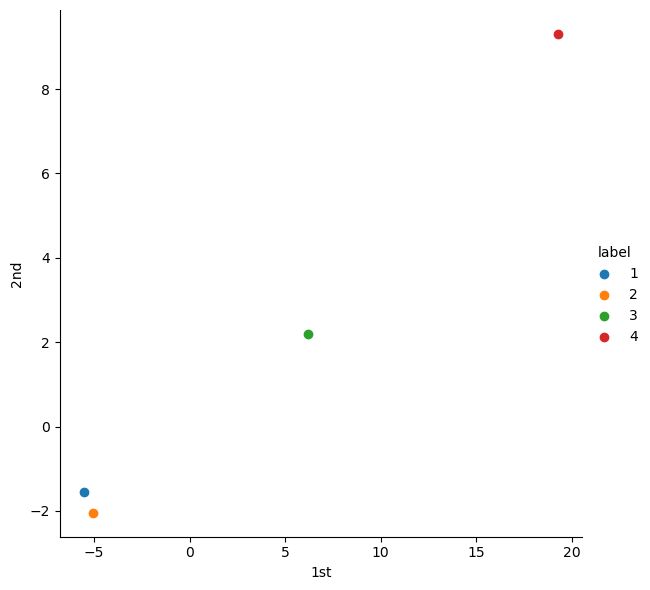

In [59]:
import seaborn as sn
import matplotlib.pyplot as plt
sn.FacetGrid(df, hue="label", height=6).map(plt.scatter, '1st', '2nd').add_legend()
plt.show()

<Axes: xlabel='1st', ylabel='2nd'>

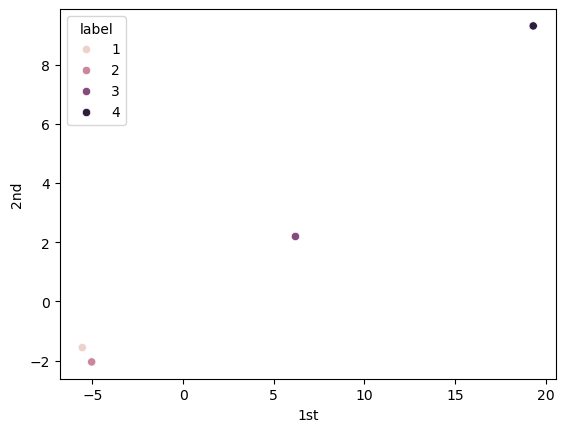

In [60]:
sn.scatterplot(x="1st",y="2nd",hue="label",data=df)

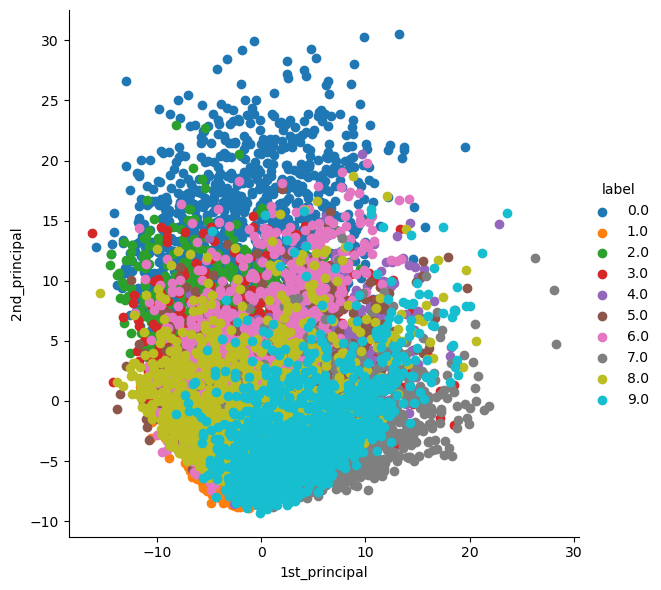

In [61]:
# ploting the 2d data points with seaborn
import seaborn as sn
sn.FacetGrid(dataframe, hue="label", height=6).map(plt.scatter, '1st_principal', '2nd_principal').add_legend()
plt.show()

<Axes: xlabel='1st_principal', ylabel='2nd_principal'>

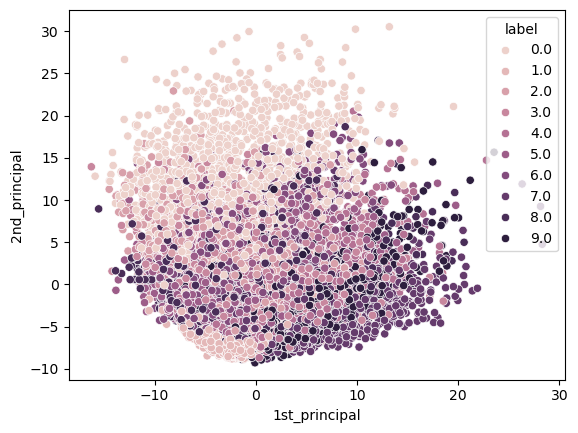

In [62]:
sn.scatterplot(x="1st_principal", y="2nd_principal", legend="full", hue="label", data=dataframe)  # scatter plot of projected PCA data with labels colored by digit q

In [63]:
# initializing the pca
from sklearn import decomposition  # import PCA functionality from scikit-learn
pca = decomposition.PCA()  # create a PCA model instance

In [64]:
# configuring the parameteres
# the number of components = 2
pca.n_components = 2  # set the PCA model to reduce data to 2 components
pca_data = pca.fit_transform(sample_data)  # fit PCA on sample data and transform it to 2D
print("shape of pca_reduced.shape = ", pca_data.shape)  # print shape of the reduced PCA output

shape of pca_reduced.shape =  (15000, 2)


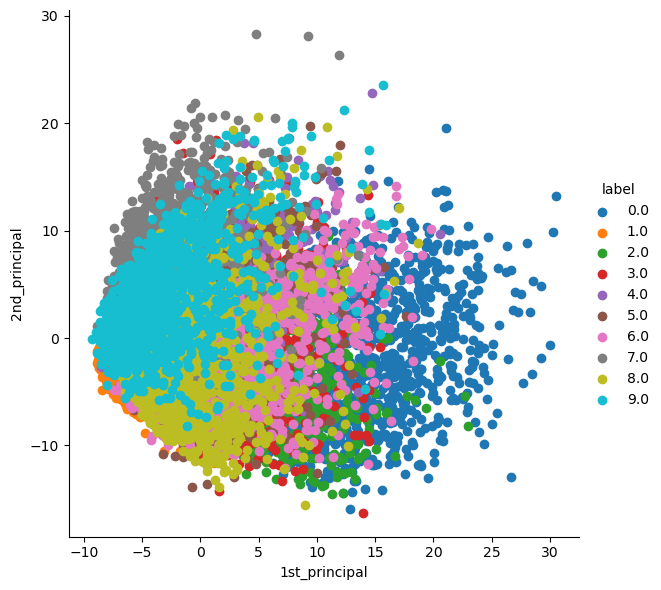

In [65]:
# attaching the label for each 2-d data point 
pca_data = np.vstack((pca_data.T, labels)).T  # stack the 2D PCA output with labels and transpose back to rows

# creating a new data fram which help us in ploting the result data
pca_df = pd.DataFrame(data=pca_data, columns=("1st_principal", "2nd_principal", "label"))  # build DataFrame for plotting
sn.FacetGrid(pca_df, hue="label", height=6).map(plt.scatter, '1st_principal', '2nd_principal').add_legend()  # plot the PCA projection by label
plt.show()  # display the PCA scatter plot

# PCA for dimensionality redcution (not for visualization)

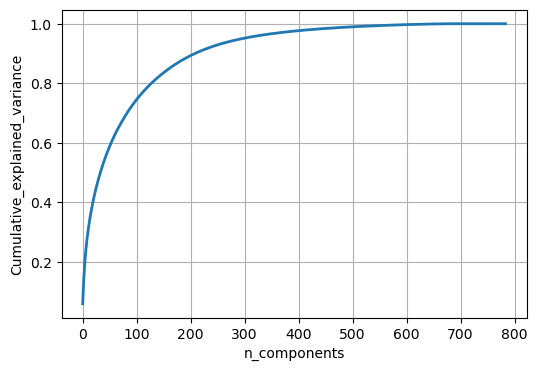

In [66]:
# PCA for dimensionality redcution (non-visualization)

pca.n_components = 784  # set PCA to compute all components for variance explanation
pca_data = pca.fit_transform(sample_data)  # fit PCA on data and produce full component projections

percentage_var_explained = pca.explained_variance_ / np.sum(pca.explained_variance_)  # fraction of variance explained by each component
cum_var_explained = np.cumsum(percentage_var_explained)  # cumulative sum of explained variance

# Plot the PCA spectrum
plt.figure(1, figsize=(6, 4))  # create a figure for the explained variance plot
plt.clf()  # clear the figure before plotting
plt.plot(cum_var_explained, linewidth=2)  # plot cumulative explained variance
plt.axis('tight')  # fit the axes tightly to the data
plt.grid()  # show a grid for easier reading
plt.xlabel('n_components')  # label the x-axis
plt.ylabel('Cumulative_explained_variance')  # label the y-axis
plt.show()  # display the explained variance plot

# If we take 200-dimensions, approx. 90% of variance is expalined.

# T-SNE using Scikit-Learn

T-SNE (T-distributed Stochastic Neighbour Embedding) it introduced in 2008  
PCA : IT tries to preserve the global space    
T SNE : IT tries to preserve the local shapes also   


### Find Neighbour  Embedding
#### Neighbour: a point and calculate the distance from this point to another point 
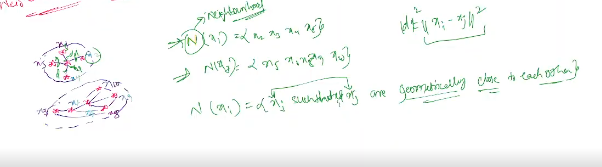


Embedding: create the 2d data points from D dimension data points   
D dimension data points transforming  and fit into 2D dimension data       
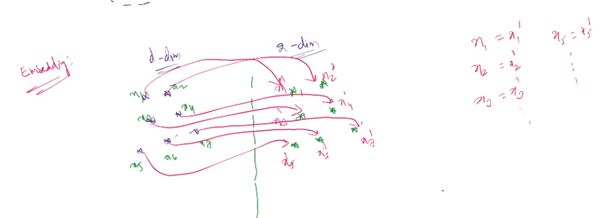

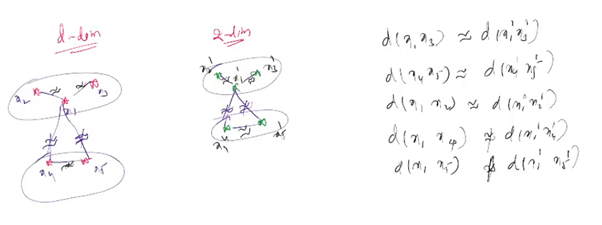

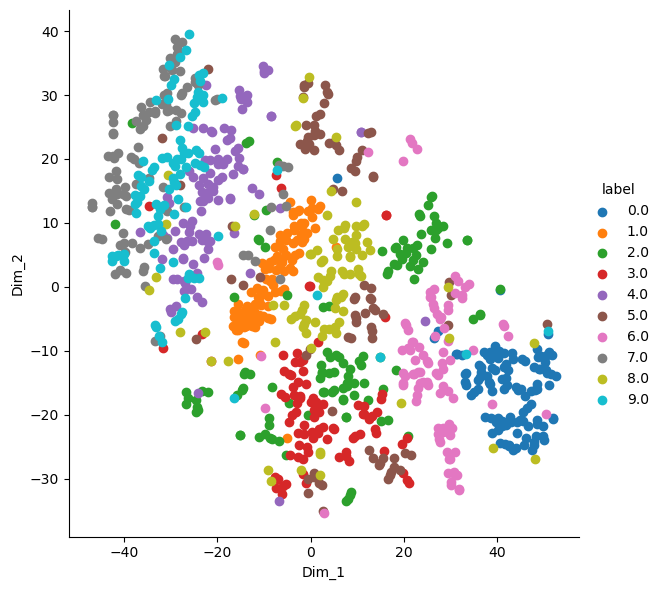

In [69]:
from sklearn.manifold import TSNE  # import t-SNE manifold learning algorithm

# Picking the top 1000 points as TSNE takes a lot of time for 15K points
data_1000 = standardized_data[0:1000, :]  # take a smaller subset for t-SNE
labels_1000 = labels[0:1000]  # take the corresponding labels for the subset

model = TSNE(n_components=2, random_state=0)  # create t-SNE model for 2D embedding
# configuring the parameteres
# the number of components = 2
# default perplexity = 30
# default learning rate = 200
# default Maximum number of iterations for the optimization = 1000

tsne_data = model.fit_transform(data_1000)  # fit t-SNE and transform the sampled data into 2D

# creating a new data frame which help us in ploting the result data
tsne_data = np.vstack((tsne_data.T, labels_1000)).T  # combine t-SNE output with labels
ntsne_df = pd.DataFrame(data=tsne_data, columns=("Dim_1", "Dim_2", "label"))  # create DataFrame for plotting

# Ploting the result of tsne
sn.FacetGrid(ntsne_df, hue="label", height=6).map(plt.scatter, 'Dim_1', 'Dim_2').add_legend()  # scatter plot of t-SNE 2D embedding
plt.show()  # display the t-SNE plot

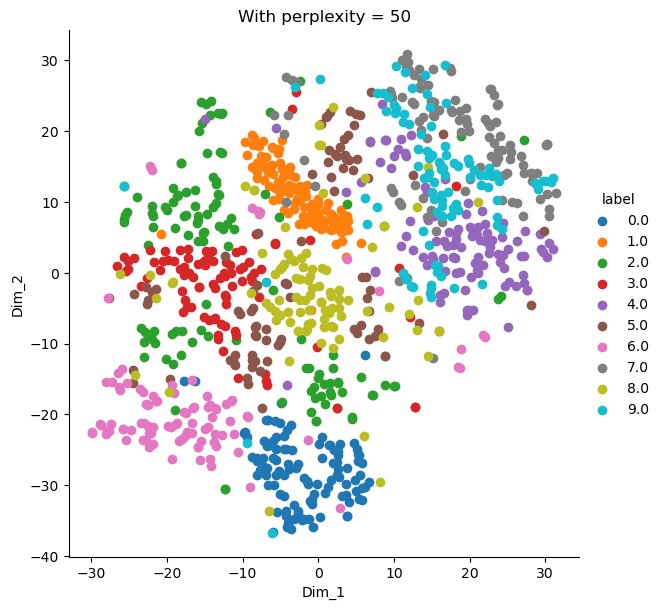

In [71]:
model = TSNE(n_components=2, random_state=0, perplexity=50)  # create t-SNE with a higher perplexity
tsne_data = model.fit_transform(data_1000)  # compute the embedding for the same subset

# creating a new data fram which help us in ploting the result data
tsne_data = np.vstack((tsne_data.T, labels_1000)).T  # combine embedded points with labels
tsne_df = pd.DataFrame(data=tsne_data, columns=("Dim_1", "Dim_2", "label"))  # build DataFrame for visualizing labeled points

# Ploting the result of tsne
sn.FacetGrid(tsne_df, hue="label", height=6).map(plt.scatter, 'Dim_1', 'Dim_2').add_legend()  # plot t-SNE embedding with labels
plt.title('With perplexity = 50')  # add a title showing the perplexity setting
plt.show()  # display the updated t-SNE plot

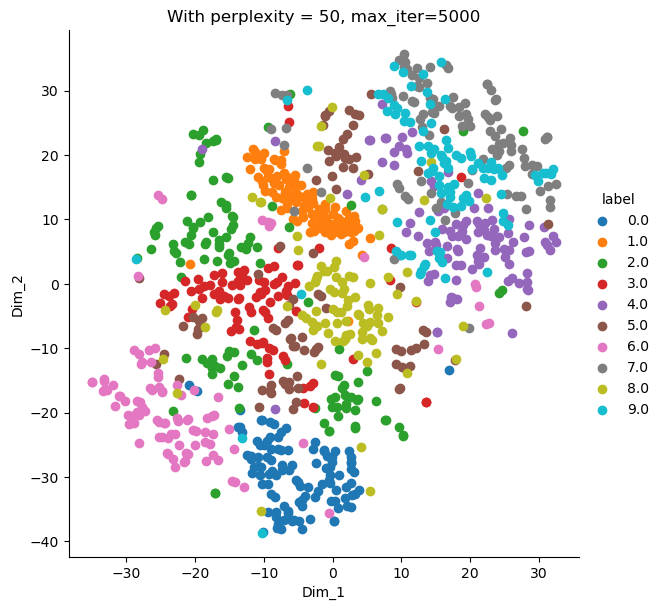

In [74]:
model = TSNE(n_components=2, random_state=0, perplexity=50, max_iter=5000)  # create t-SNE with more iterations for better convergence
tsne_data = model.fit_transform(data_1000)  # compute the embedding with extended optimization

# creating a new data fram which help us in ploting the result data
tsne_data = np.vstack((tsne_data.T, labels_1000)).T  # add labels to embedding coordinates
tsne_df = pd.DataFrame(data=tsne_data, columns=("Dim_1", "Dim_2", "label"))  # prepare DataFrame for plotting

# Ploting the result of tsne
sn.FacetGrid(tsne_df, hue="label", height=6).map(plt.scatter, 'Dim_1', 'Dim_2').add_legend()  # plot the improved t-SNE map
plt.title('With perplexity = 50, max_iter=5000')  # add title with iteration and perplexity settings
plt.show()  # show the figure

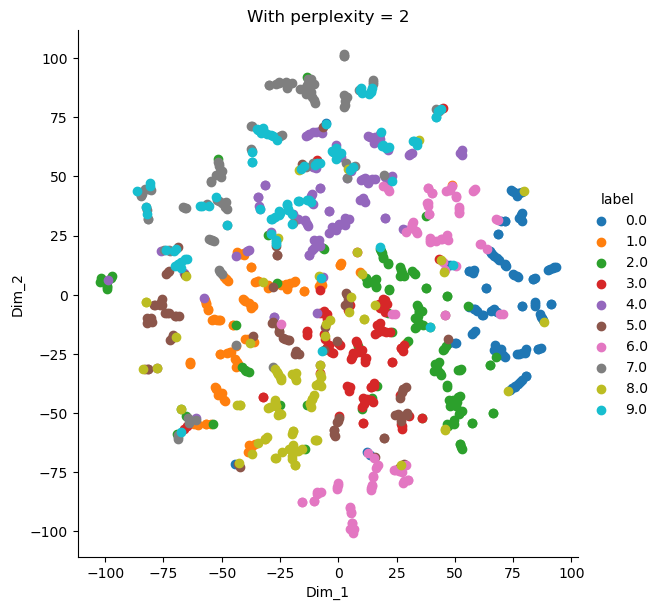

In [76]:
model = TSNE(n_components=2, random_state=0, perplexity=2)  # create t-SNE with a very low perplexity value
tsne_data = model.fit_transform(data_1000)  # run t-SNE embedding for the low perplexity setting

# creating a new data fram which help us in ploting the result data
tsne_data = np.vstack((tsne_data.T, labels_1000)).T  # stack the embedding coordinates with labels
tsne_df = pd.DataFrame(data=tsne_data, columns=("Dim_1", "Dim_2", "label"))  # create DataFrame for plotting

# Ploting the result of tsne
sn.FacetGrid(tsne_df, hue="label", height=6).map(plt.scatter, 'Dim_1', 'Dim_2').add_legend()  # plot the low-perplexity t-SNE embedding
plt.title('With perplexity = 2')  # title indicating the perplexity value used
plt.show()  # display the plot